<a href="https://colab.research.google.com/github/carlxen/CCMACLRL_EXERCISES_COM232/blob/main/Exercise5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5: Create your own personal face recognition using SVM

## Instructions:

Create a directory in your google drive using this folder structure

```
My Drive
- Images
  - Train
    - Elizer
    - Eliza
  - Test
```

- Upload 90 images of your self (selfied are recommended) in the Train folder
- Upload 90 images of your partner in the Train folder
- Upload 20 images of yourself and your partner in the Test Folder
- Use **.png** or **.jpg** or **.jpeg** images files

In [23]:
pip install numpy opencv-python scikit-learn

## Import libraries

In [24]:
import os
import cv2
import numpy as np
from PIL import Image  # PIL is used to load the image
import matplotlib.pyplot as plt

## Mount Google Drive

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Display one raw image directly from your drive

In [26]:
# put your answer here
def displayImage(image_path):
  #path to you image file in gg drive
  image = Image.open(image_path)

  #display the image using matplotlib
  plt.imshow(image)
  plt.axis('on')
  plt.show()

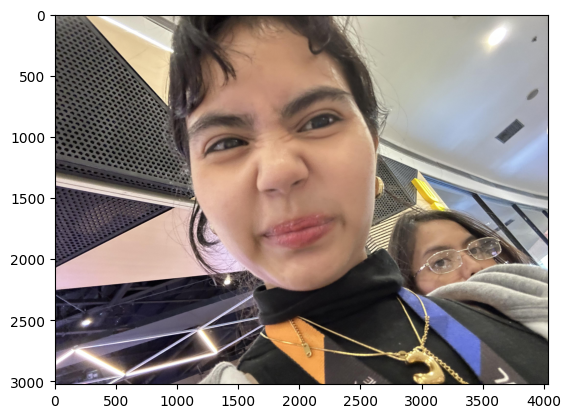

In [27]:
displayImage('/content/drive/My Drive/selfie dataset/Images/Train/Xen/Copy of Copy of IMG_3794.jpg')

## 2. Load the images from your drive and apply preprocessing to your raw images

In [28]:
# put your answer here
def load_images_from_folder(folder):
    images = []
    labels = []
    for label, person in enumerate(os.listdir(folder)):
        person_folder = os.path.join(folder, person)
        person_name = os.path.basename(person_folder)
        for filename in os.listdir(person_folder):
            img_path = os.path.join(person_folder, filename)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
            img = cv2.resize(img, (100, 100))  # Resize to 100x100 pixels
            images.append(img.flatten())  # Flatten the image
            labels.append(person_name)
    return np.array(images), np.array(labels)


In [29]:
images, labels = load_images_from_folder('/content/drive/My Drive/selfie dataset/Images/Train')

In [30]:
images.shape

(190, 10000)

In [31]:
labels.shape

(190,)

In [32]:
labels

array(['Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen', 'Xen',
       'Xen', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid',
       'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid',
       'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid', 'Rid',
       'Rid', 'Rid',

## 3. Display one pre-processed image from the training set

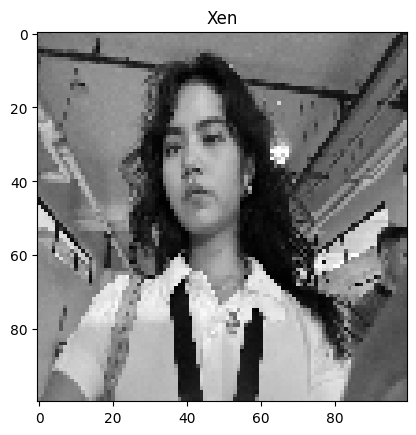

In [33]:
# put your answer here
# Get a sample image and its corresponding name
image = images[0].reshape(100,100)  # Access the first image
name = labels[0]  # Get the name corresponding to the image

# Display the image
plt.imshow(image, cmap="gray")
plt.title(name)
plt.axis('on')  # Hide axes
plt.show()

## 4. Display ten pre-processed images from the training set

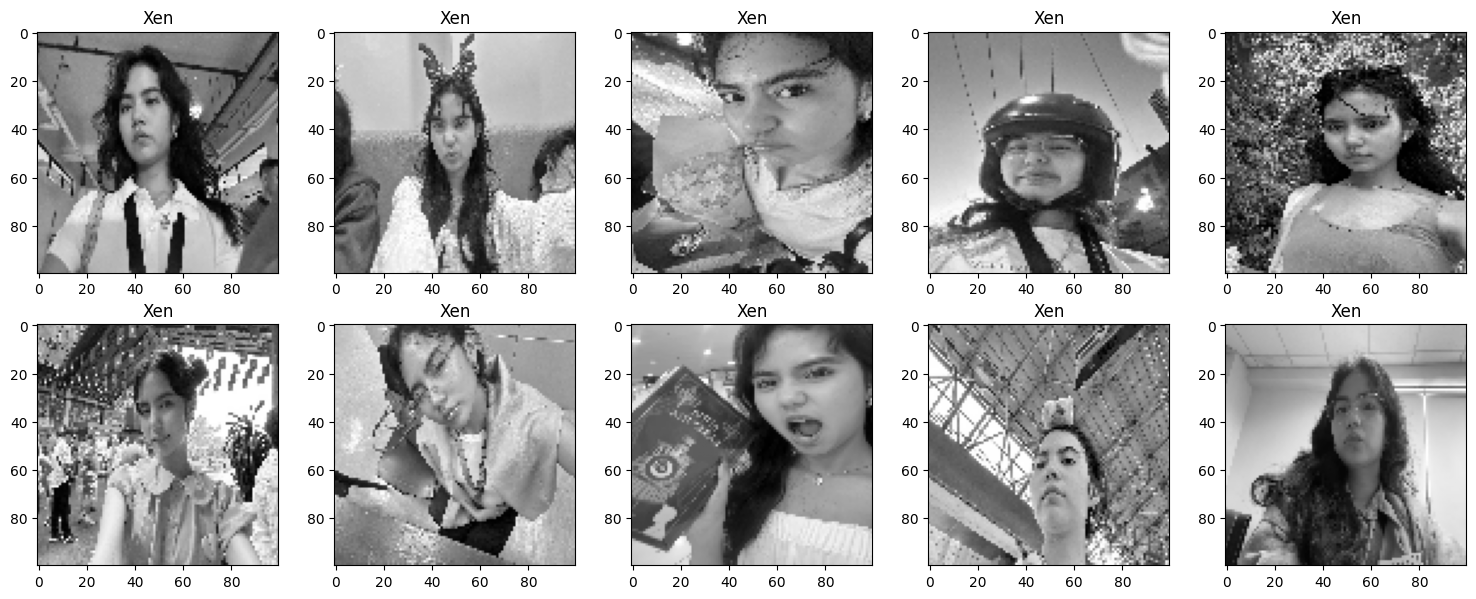

In [34]:
# put your answer here
num_faces = 10

fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows and 5 columns
axes = axes.flatten()  # Flatten the array of axes for easy indexing

# Loop to display the images
for i in range(num_faces):
    image = images[i].reshape(100,100)  # Access the i-th image
    name = labels[i]  # Get the name corresponding to the image

    axes[i].imshow(image, cmap='gray')  # Show the image
    axes[i].set_title(name)  # Set the title to the name
    axes[i].axis('on')  # Hide axes

# Adjust layout
plt.tight_layout()
plt.show()

## 5. Split your training data

In [35]:
# put your answer here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

## 6. Train your SVM model

In [36]:
# put your answer here
from sklearn import svm

model = svm.SVC(gamma='scale')
model.fit(X_train, y_train)

SVC()

## 7. Evaluate your SVM model

In [40]:
# put your answer here
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 76.32%


## 8. Test your model using images not in your training set

Use your SVM model to predict the label of all of your images in the Test folder

In [38]:
# put your answer here
def predict_image(img_path, model):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (100, 100)).flatten().reshape(1, -1)  # Flatten and reshape for prediction
    prediction = model.predict(img)
    return prediction

Predicted label: ['Xen']


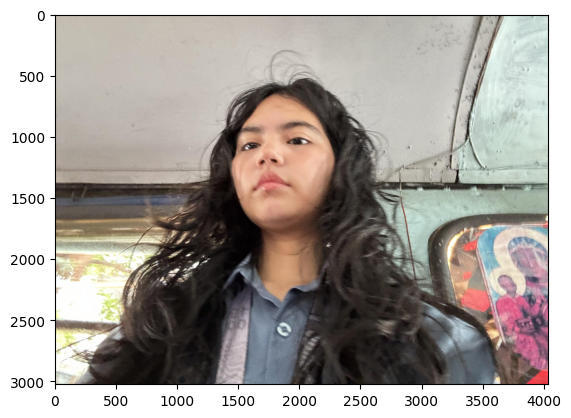

In [39]:
img_path = '/content/drive/My Drive/selfie dataset/Images/Test/Copy of Copy of Copy of IMG_8381.jpg'
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

In [42]:
import pandas as pd

def load_test_images_from_folder(folder):
    images = []
    filenames = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        img = cv2.resize(img, (100, 100))  # Resize to 100x100 pixels
        images.append(img.flatten())  # Flatten the image
        filenames.append(filename)
    return np.array(images), np.array(filenames)

# Load test images
test_images, test_filenames = load_test_images_from_folder('/content/drive/My Drive/selfie dataset/Images/Test')

# Make predictions on test images
test_predictions = model.predict(test_images)

# Create submission DataFrame
submission_df = pd.DataFrame({
    'Filename': test_filenames,
    'Predicted_Label': test_predictions
})

# Save the submission DataFrame to a CSV file
submission_df.to_csv('submission_file.csv', index=False)

print("Submission file created: submission_file.csv")

Submission file created: submission_file.csv
